# Загрузка библиотек

In [63]:
import pandas as pd
import numpy as np
import chardet
from sqlalchemy import create_engine
from scipy.stats import normaltest, skew, chi2_contingency, kruskal
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
import pickle
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

# Загрузка датасета

In [2]:
def get_encoding(filepath: str):
    '''
    Получение кодировки файла
    '''

    # Чтение файла в бинарном формате
    with open(filepath, 'rb') as f:
        data = f.read()

    # Определение кодировки с помощью библиотеки chardet
    encoding_result = chardet.detect(data)

    # Получение информации из результата детекции
    encoding = encoding_result['encoding']

    return encoding

In [3]:
filepath = "data/water_pollution_disease.csv" # Путь до файла
encoding = get_encoding(filepath) # Кодировка документа (узнать через Блокнот/через код)
sep = "," # Разделитель данных (открой файл и посмотри)

data = pd.read_csv(filepath, encoding=encoding, sep=sep)

data.head()

,Country,Region,Year,Water Source Type,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),...,"Cholera Cases per 100,000 people","Typhoid Cases per 100,000 people","Infant Mortality Rate (per 1,000 live births)",GDP per Capita (USD),Healthcare Access Index (0-100),Urbanization Rate (%),Sanitation Coverage (% of Population),Rainfall (mm per year),Temperature (°C),Population Density (people per km²)
0,Mexico,North,2015,Lake,6.06,7.12,3.93,4.28,8.28,7.89,...,33,44,76.16,57057,96.92,84.61,63.23,2800,4.94,593
1,Brazil,West,2017,Well,5.24,7.84,4.79,3.86,15.74,14.68,...,27,8,77.30,17220,84.73,73.37,29.12,1572,16.93,234
2,Indonesia,Central,2022,Pond,0.24,6.43,0.79,3.42,36.67,9.96,...,39,50,48.45,86022,58.37,72.86,93.56,2074,21.73,57
3,Nigeria,East,2016,Well,7.91,6.71,1.96,3.12,36.92,6.77,...,33,13,95.66,31166,39.07,71.07,94.25,937,3.79,555
4,Mexico,South,2005,Well,0.12,8.16,4.22,9.15,49.35,12.51,...,31,68,58.78,25661,23.03,55.55,69.23,2295,31.44,414


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Country                                        3000 non-null   object 
 1   Region                                         3000 non-null   object 
 2   Year                                           3000 non-null   int64  
 3   Water Source Type                              3000 non-null   object 
 4   Contaminant Level (ppm)                        3000 non-null   float64
 5   pH Level                                       3000 non-null   float64
 6   Turbidity (NTU)                                3000 non-null   float64
 7   Dissolved Oxygen (mg/L)                        3000 non-null   float64
 8   Nitrate Level (mg/L)                           3000 non-null   float64
 9   Lead Concentration (µg/L)                      3000 

# Загрузка в базу данных

In [4]:
def get_conn(dbname, user, password, host):
    url = f"postgresql+psycopg2://{user}:{password}@{host}/{dbname}"
    return create_engine(url)

In [5]:
dbname = "Regression_data" # Название базы данных
user = "postgres" # Имя пользователя для подключения
password = "86754231qaZ" # Пароль пользователя для подключения
host = "localhost" # Хост


conn = get_conn(dbname, user, password, host)

In [9]:
table_name = "water_pollution" # Название новой таблицы
if_exists = "replace" # Поведение, если таблица уже существует
index = False # Сохранять ли индекс в отдельную колонку

data.to_sql(name=table_name, con=conn, if_exists=if_exists, index=index)

1000

# Анализ данных

<b>Описание столбцов</b>

* Contry - страна
* Region - регион
* Year - год
* Water Source Type - тип водного источника
* Contaminant Level - уровень загрязняющих веществ
* pH Level - уровень pH
* Turbidity (NTU) - мутность
* Dissolved Oxygen (mg/L) - растворённый кислород
* Nitrate Level (mg/L) - уровень нитратов
* Lead Concentration (µg/L) - концентрация свинца
* Bacteria Count (CFU/mL) - кол-во бактерий
* Water Treatment Method - метод очистки воды
* Access to Clean Water (% of Population) - доступ к чистой воде (% населения)
* Diarrheal Cases per 100,000 people  - случаи диареи на 100,000 человек
* Cholera Cases per 100,000 people - случаи холеры на 100,000 человек
* Typhoid Cases per 100,000 people - случаи брюшного тифа на 100,000 человек
* Infant Mortality Rate (per 1,000 live births) - коэффициент младенчиской смертности (на 1000 живорождённий)
* GDP per Capita (USD) - ВВП на душу населения (в долларах США)
* Healthcare Access Index (0-100) - индекс доступности здравоохранения
* Urbanization Rate (%) - уровень урбанизации
* Sanitation Coverage (% of Population) - охват санитарными услугами (% населения)
* Rainfall (mm per year) - кол-во осадков (мм в год)
* Temperature (°C) - температура воздуха (°C)
* Population Density (people per km²) - плотность населения (чел./км2)

## Борьба с пустыми значениями

In [6]:
data["Water Treatment Method"].unique()

array(['Filtration', 'Boiling', nan, 'Chlorination'], dtype=object)

Вероятнее всего отсутствие значений указывает на то, что вода не очищалась, так что заменим значения

In [7]:
data["Water Treatment Method"] = data["Water Treatment Method"].fillna("Nothing")

In [10]:
table_name = "water_pollution" # Название новой таблицы
if_exists = "replace" # Поведение, если таблица уже существует
index = False # Сохранять ли индекс в отдельную колонку

data.to_sql(name=table_name, con=conn, if_exists=if_exists, index=index)

1000

Заменим данные на обработанные в базе данных.

## Анализ распределения

### Числовые признаки

In [11]:
# Отбор числовых признаков
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']

numeric_data = data.select_dtypes(include=numerics)

In [43]:
numeric_data.describe()

,Year,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),Bacteria Count (CFU/mL),Access to Clean Water (% of Population),"Diarrheal Cases per 100,000 people","Cholera Cases per 100,000 people","Typhoid Cases per 100,000 people","Infant Mortality Rate (per 1,000 live births)",GDP per Capita (USD),Healthcare Access Index (0-100),Urbanization Rate (%),Sanitation Coverage (% of Population),Rainfall (mm per year),Temperature (°C),Population Density (people per km²)
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2012.012667,4.954390,7.255847,2.480023,6.492850,25.08025,10.047913,2488.477333,64.612333,249.776667,24.25100,49.270000,50.811900,50036.196667,50.029193,50.062480,60.371007,1591.849000,20.130917,505.390333
std,7.229287,2.860072,0.720464,1.419984,2.027966,14.50517,5.798238,1431.421553,20.308463,144.111543,14.33259,28.984165,28.465323,28598.750508,28.896676,22.779125,23.159678,817.502434,11.689244,283.275224
min,2000.000000,0.000000,6.000000,0.000000,3.000000,0.05000,0.000000,0.000000,30.010000,0.000000,0.00000,0.000000,2.060000,521.000000,0.190000,10.030000,20.010000,200.000000,0.060000,10.000000
25%,2006.000000,2.560000,6.630000,1.257500,4.710000,12.52500,5.120000,1268.000000,47.027500,124.000000,12.00000,24.000000,26.467500,25010.250000,24.982500,30.557500,40.440000,865.750000,9.840000,254.750000
50%,2012.000000,4.950000,7.280000,2.460000,6.490000,24.79000,10.065000,2469.000000,64.780000,248.000000,24.00000,49.000000,50.230000,49621.500000,50.390000,49.795000,60.580000,1572.000000,20.175000,513.000000
75%,2018.000000,7.400000,7.870000,3.660000,8.252500,37.91000,15.032500,3736.250000,82.302500,378.000000,37.00000,75.000000,76.260000,74778.250000,74.817500,69.727500,80.420000,2308.250000,30.672500,745.000000
max,2024.000000,10.000000,8.500000,4.990000,10.000000,49.99000,20.000000,4998.000000,99.990000,499.000000,49.00000,99.000000,99.990000,99948.000000,99.980000,89.980000,99.990000,2999.000000,39.990000,999.000000


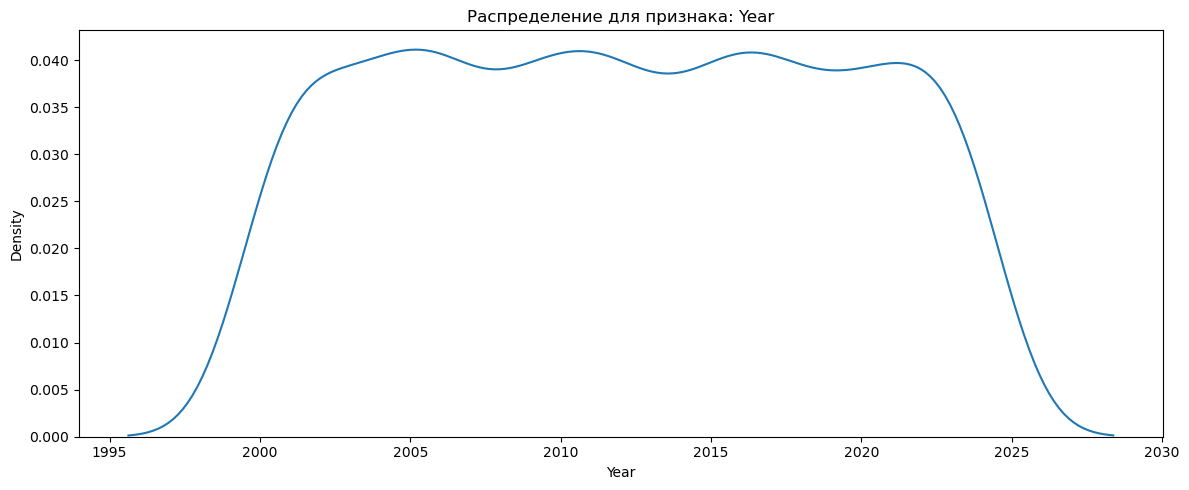

По тесту Д’Агостино-Пирсона нормальность распределения Year: False
Скошенность распределения Year: Не выявлено


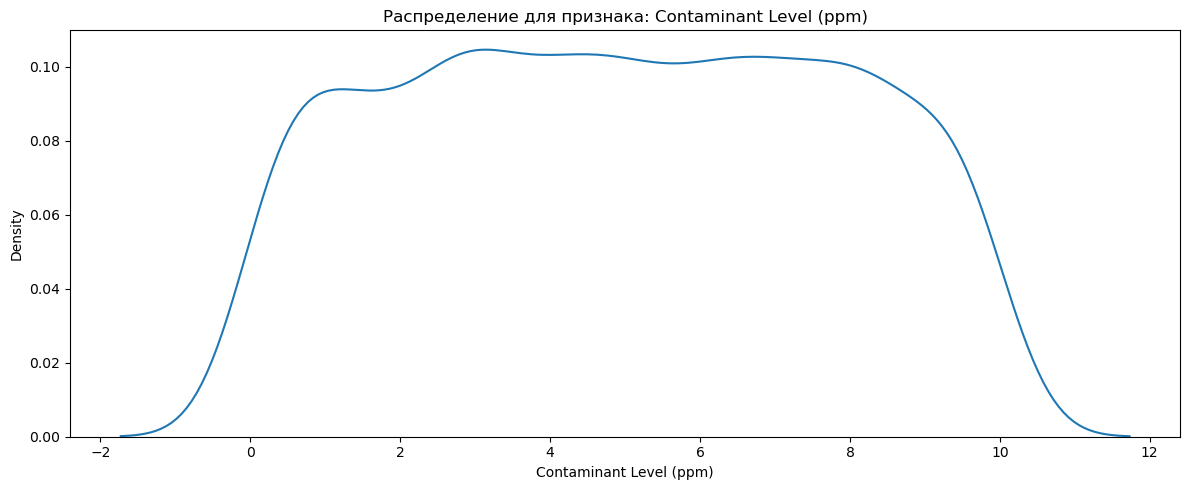

По тесту Д’Агостино-Пирсона нормальность распределения Contaminant Level (ppm): False
Скошенность распределения Contaminant Level (ppm): Не выявлено


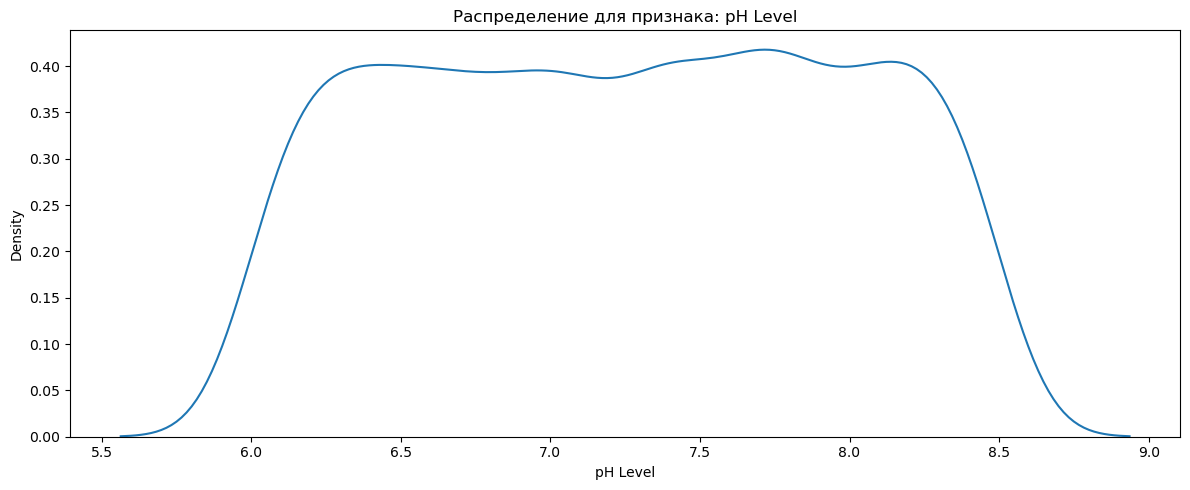

По тесту Д’Агостино-Пирсона нормальность распределения pH Level: False
Скошенность распределения pH Level: Не выявлено


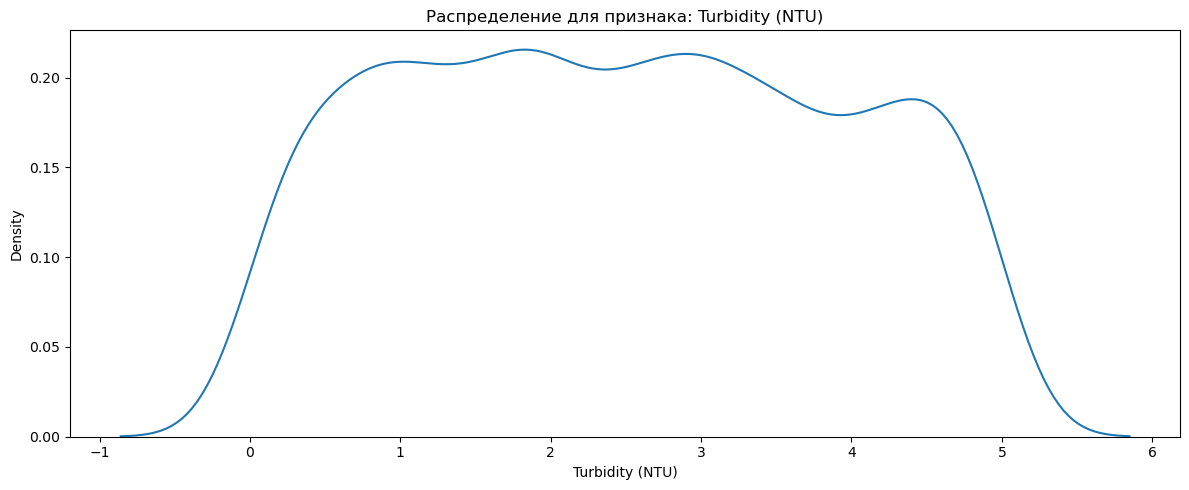

По тесту Д’Агостино-Пирсона нормальность распределения Turbidity (NTU): False
Скошенность распределения Turbidity (NTU): Не выявлено


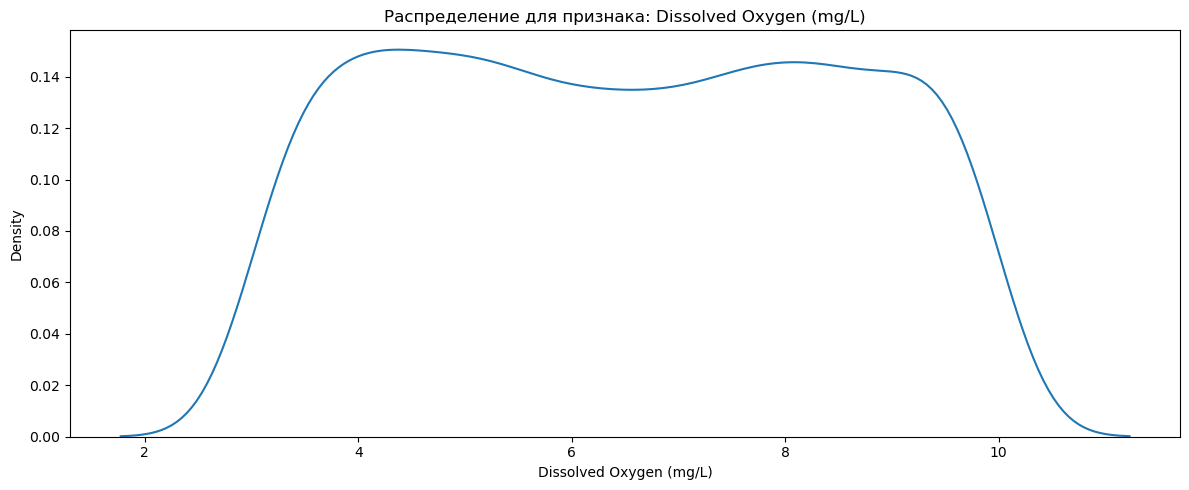

По тесту Д’Агостино-Пирсона нормальность распределения Dissolved Oxygen (mg/L): False
Скошенность распределения Dissolved Oxygen (mg/L): Не выявлено


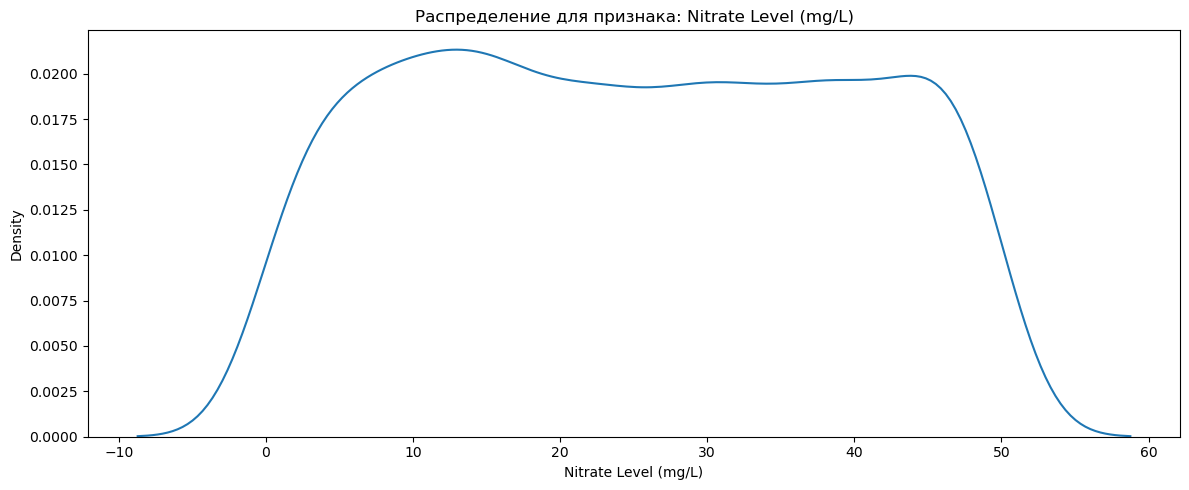

По тесту Д’Агостино-Пирсона нормальность распределения Nitrate Level (mg/L): False
Скошенность распределения Nitrate Level (mg/L): Не выявлено


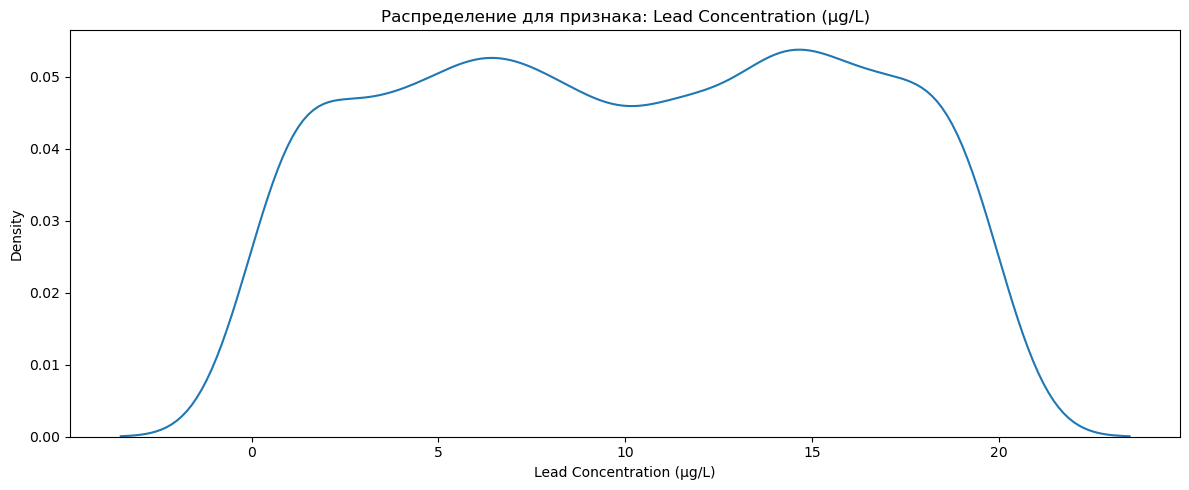

По тесту Д’Агостино-Пирсона нормальность распределения Lead Concentration (µg/L): False
Скошенность распределения Lead Concentration (µg/L): Не выявлено


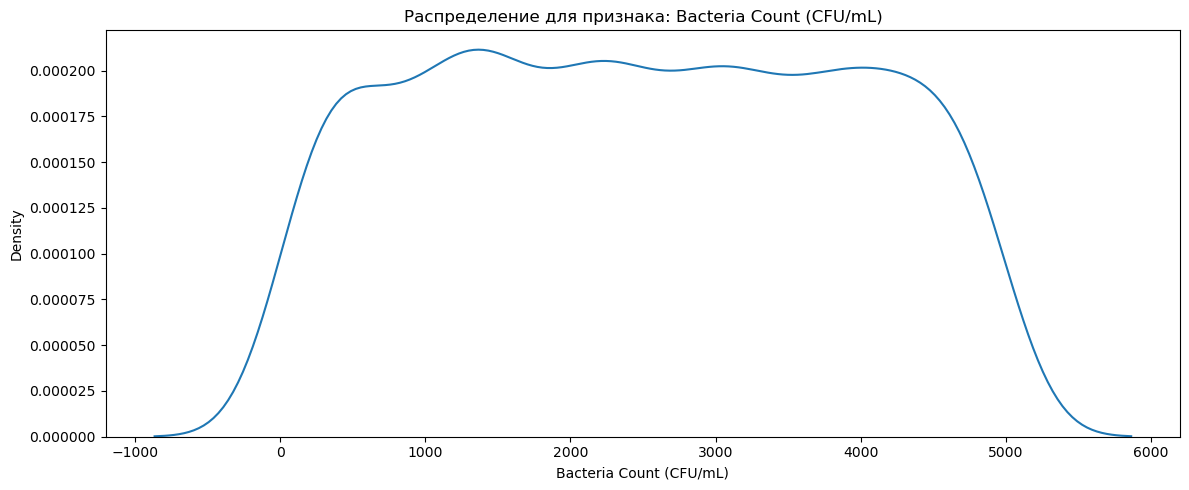

По тесту Д’Агостино-Пирсона нормальность распределения Bacteria Count (CFU/mL): False
Скошенность распределения Bacteria Count (CFU/mL): Не выявлено


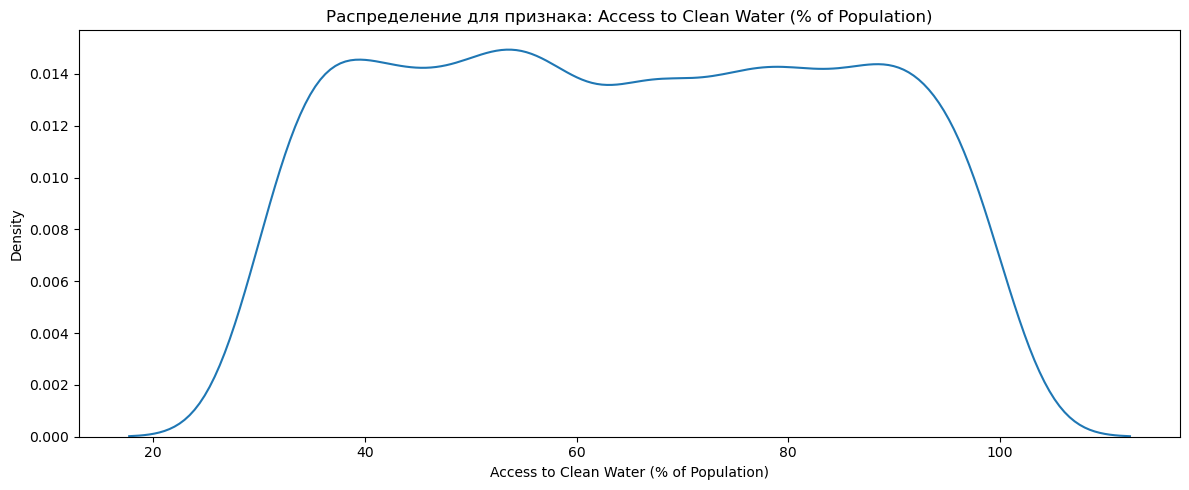

По тесту Д’Агостино-Пирсона нормальность распределения Access to Clean Water (% of Population): False
Скошенность распределения Access to Clean Water (% of Population): Не выявлено


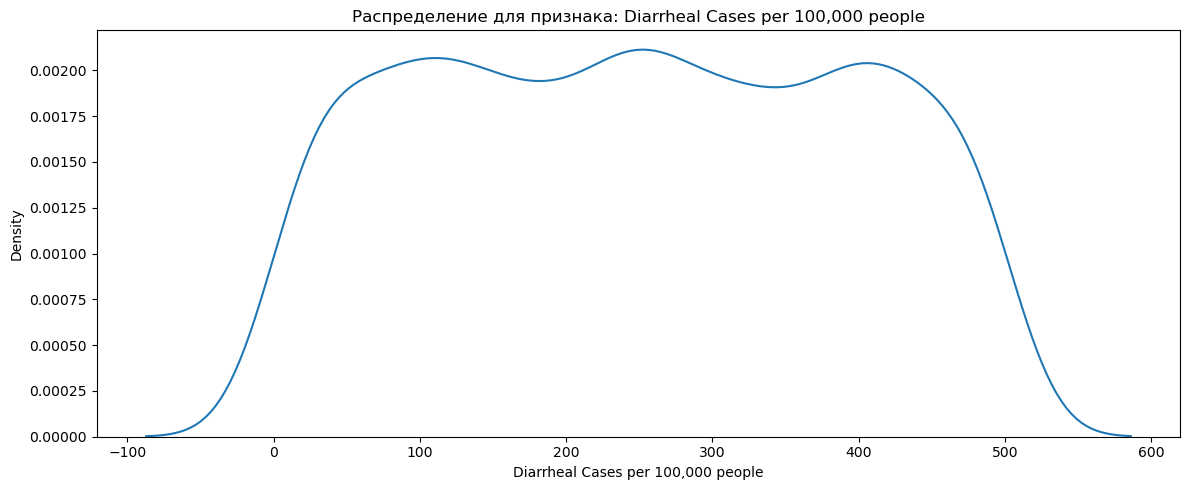

По тесту Д’Агостино-Пирсона нормальность распределения Diarrheal Cases per 100,000 people: False
Скошенность распределения Diarrheal Cases per 100,000 people: Не выявлено


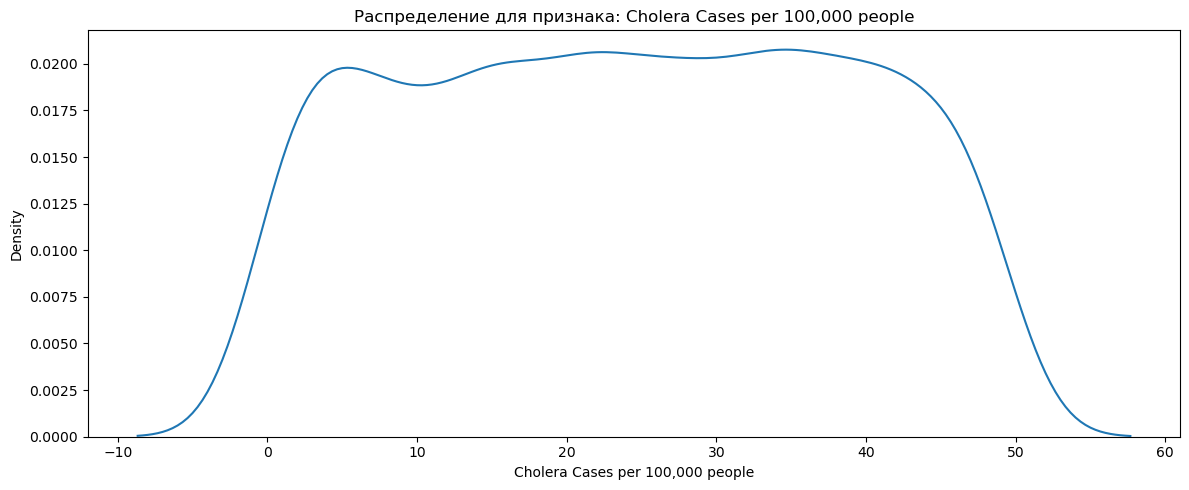

По тесту Д’Агостино-Пирсона нормальность распределения Cholera Cases per 100,000 people: False
Скошенность распределения Cholera Cases per 100,000 people: Не выявлено


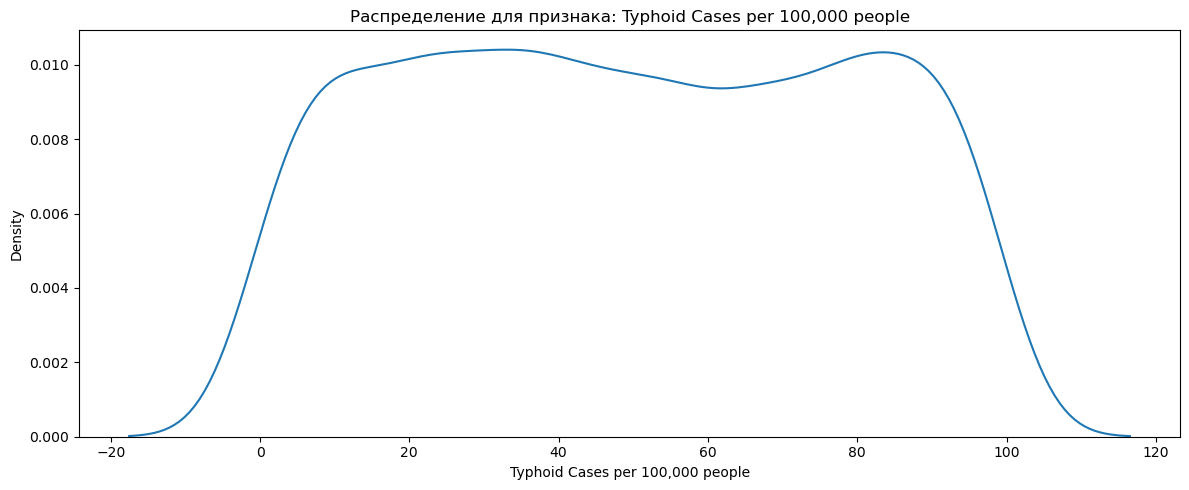

По тесту Д’Агостино-Пирсона нормальность распределения Typhoid Cases per 100,000 people: False
Скошенность распределения Typhoid Cases per 100,000 people: Не выявлено


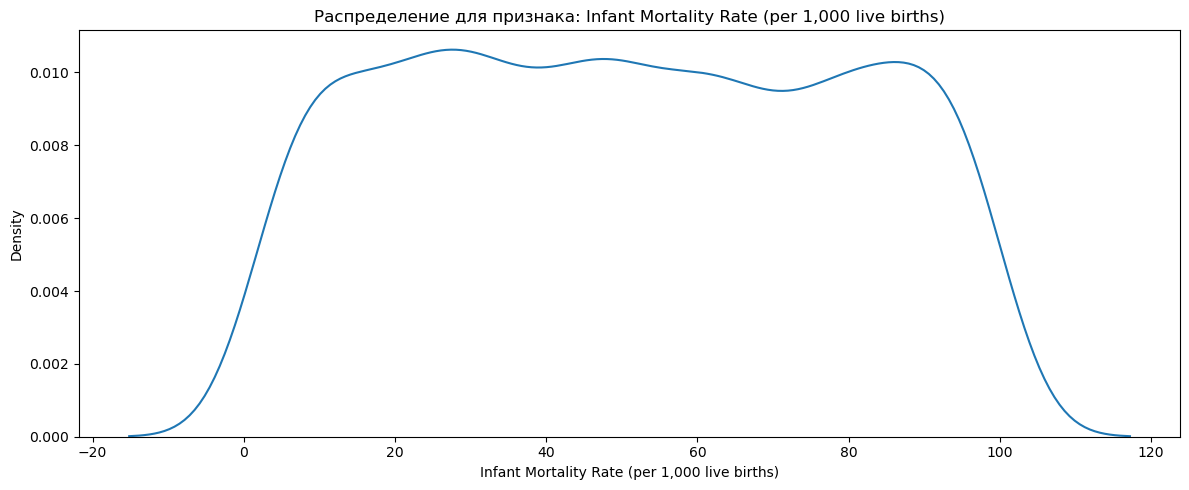

По тесту Д’Агостино-Пирсона нормальность распределения Infant Mortality Rate (per 1,000 live births): False
Скошенность распределения Infant Mortality Rate (per 1,000 live births): Не выявлено


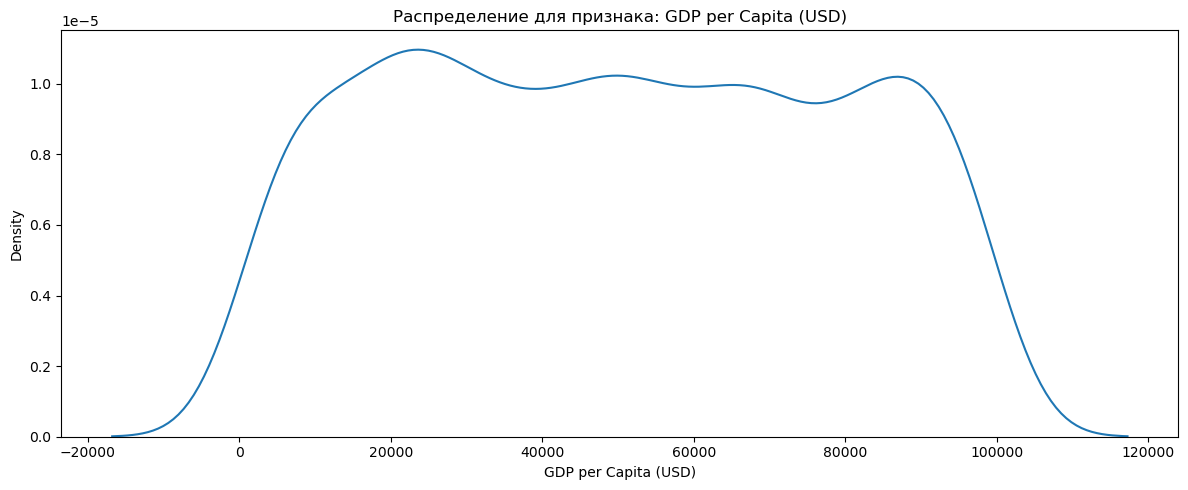

По тесту Д’Агостино-Пирсона нормальность распределения GDP per Capita (USD): False
Скошенность распределения GDP per Capita (USD): Не выявлено


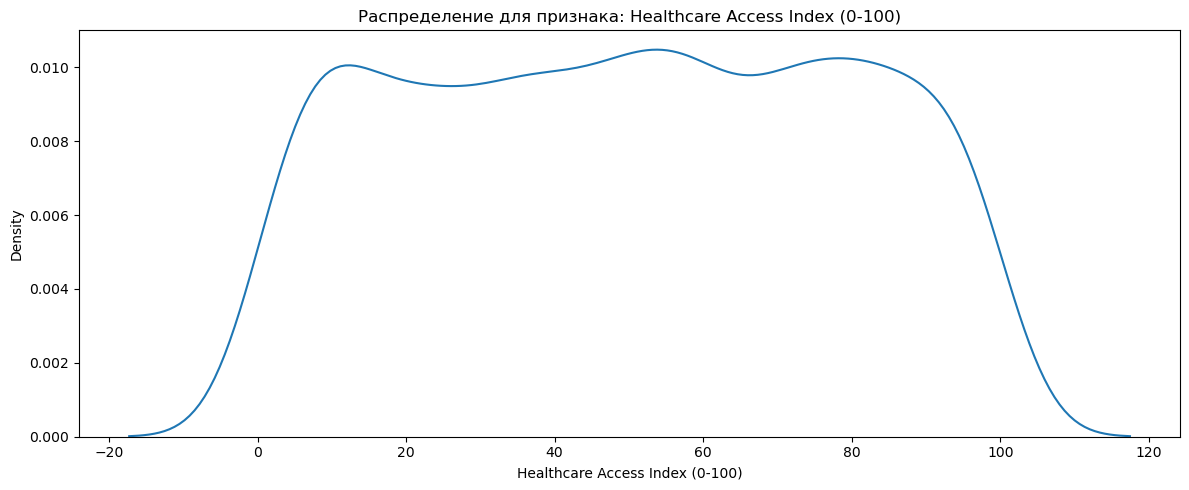

По тесту Д’Агостино-Пирсона нормальность распределения Healthcare Access Index (0-100): False
Скошенность распределения Healthcare Access Index (0-100): Не выявлено


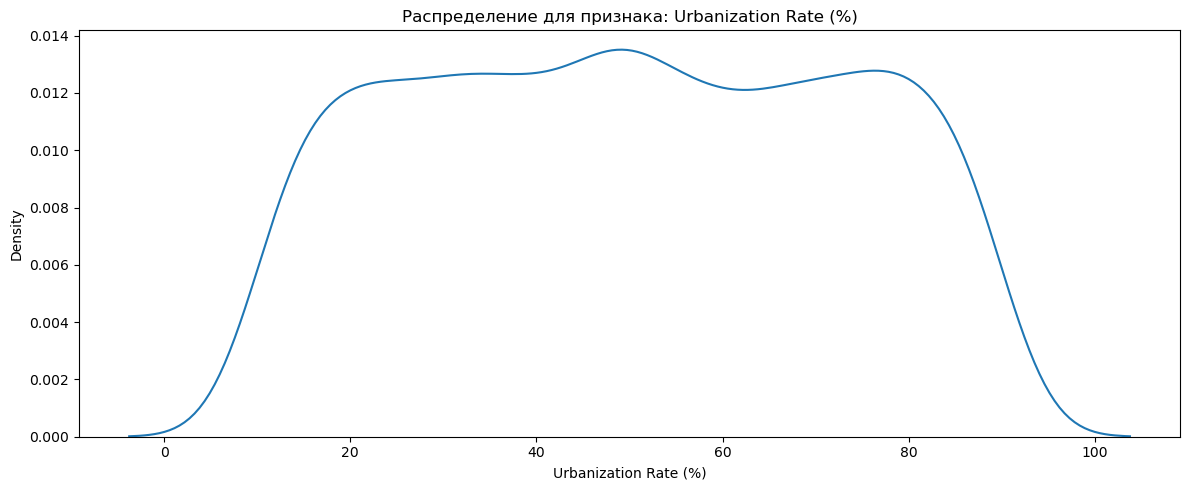

По тесту Д’Агостино-Пирсона нормальность распределения Urbanization Rate (%): False
Скошенность распределения Urbanization Rate (%): Не выявлено


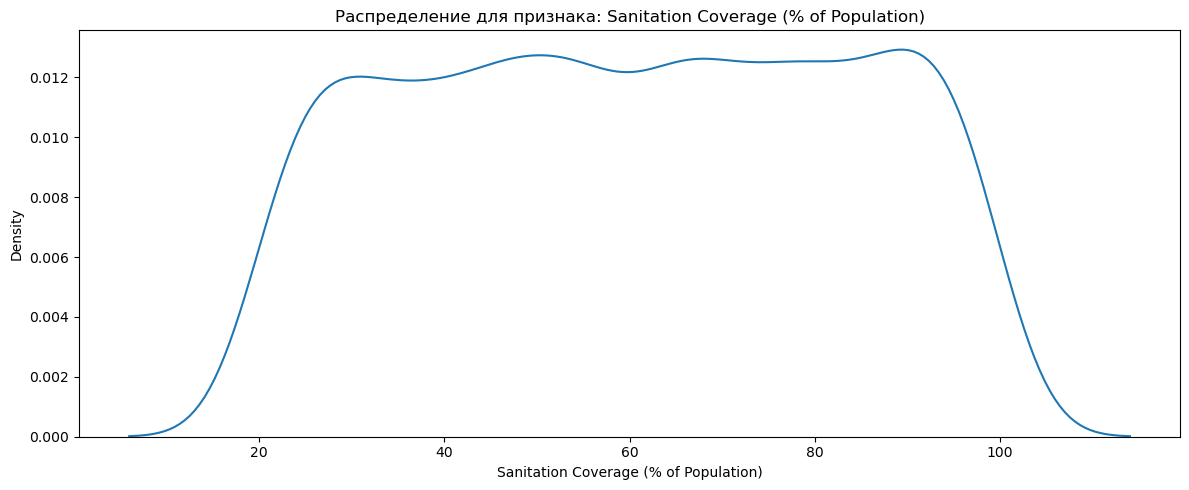

По тесту Д’Агостино-Пирсона нормальность распределения Sanitation Coverage (% of Population): False
Скошенность распределения Sanitation Coverage (% of Population): Не выявлено


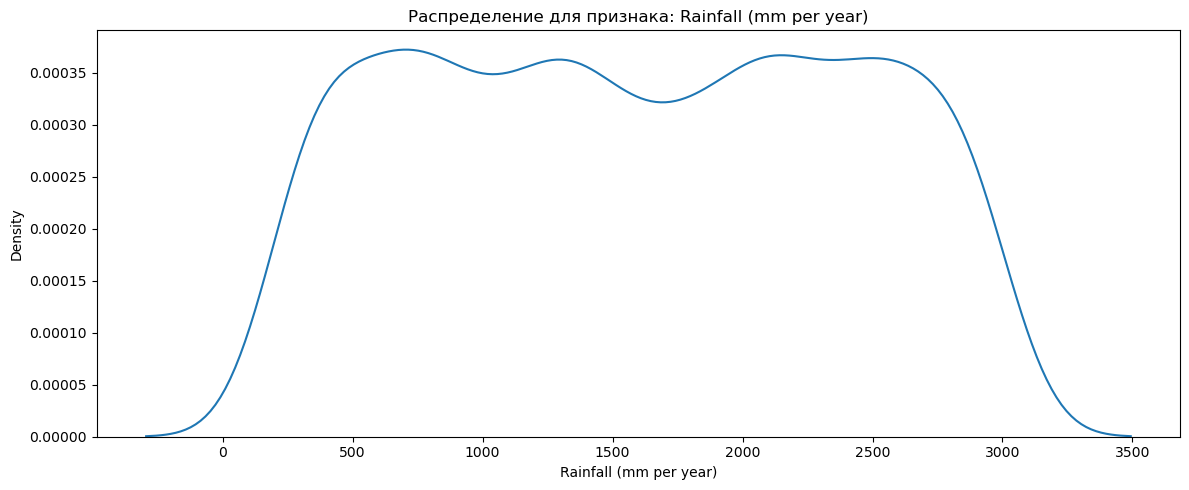

По тесту Д’Агостино-Пирсона нормальность распределения Rainfall (mm per year): False
Скошенность распределения Rainfall (mm per year): Не выявлено


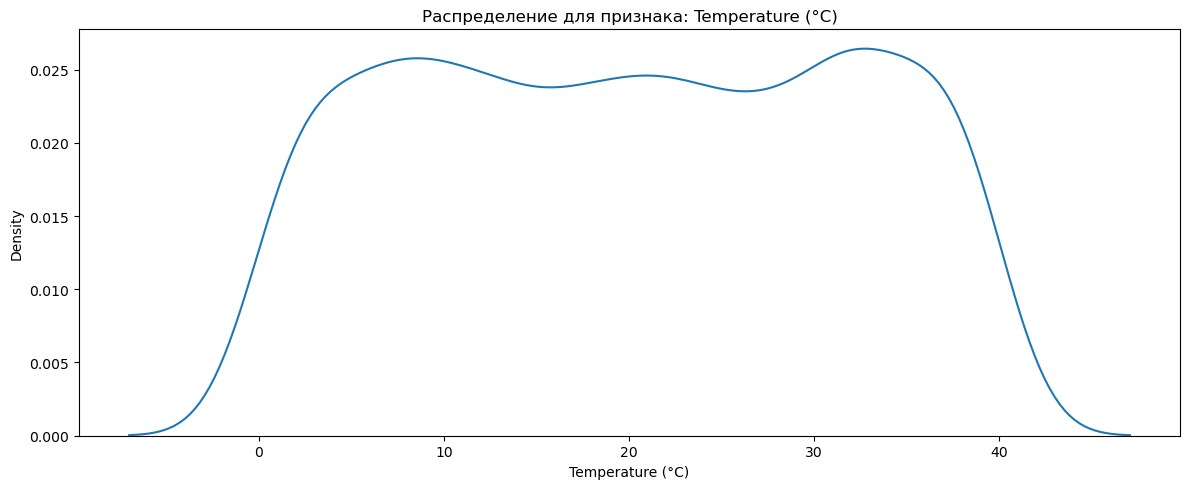

По тесту Д’Агостино-Пирсона нормальность распределения Temperature (°C): False
Скошенность распределения Temperature (°C): Не выявлено


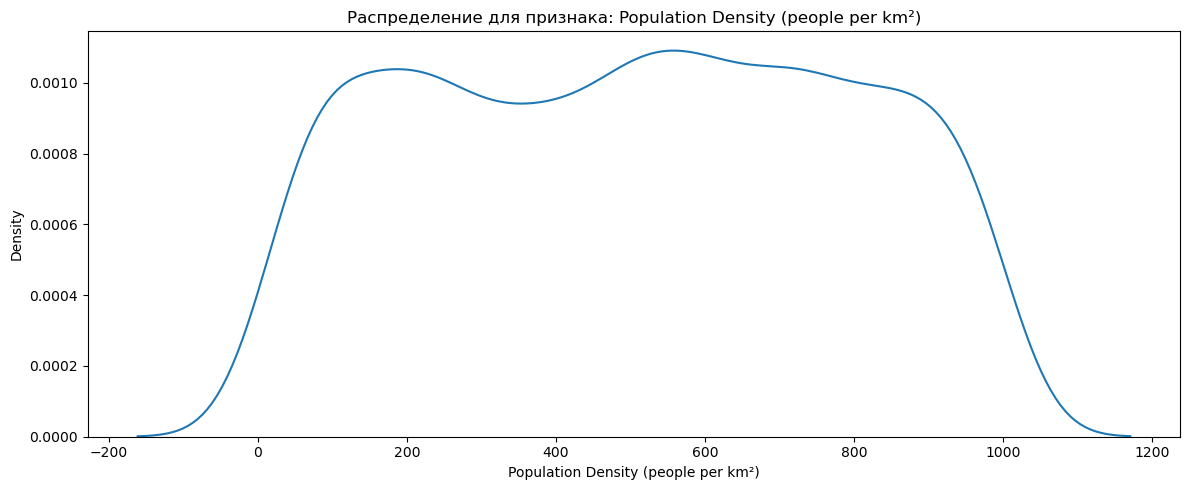

По тесту Д’Агостино-Пирсона нормальность распределения Population Density (people per km²): False
Скошенность распределения Population Density (people per km²): Не выявлено


In [13]:
# Тест Д’Агостино-Пирсона
def execute_normaltest(data):
    result = normaltest(data)
    p_value = result[1]
    
    return p_value

# Тест на ассиметрию
def get_assymetry(data):
    result = skew(data)

    if result > 0.1:
        return "Влево"
    elif result < -0.1:
        return "Вправо"
    return "Не выявлено"

def visual_distribution(data, column):

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.kdeplot(data=data, x=column, ax=ax)
    ax.set_title(f"Распределение для признака: {column}")

    fig.tight_layout()
    plt.show()

    normaltest_p_value = execute_normaltest(data[column])
    print(f"По тесту Д’Агостино-Пирсона нормальность распределения {column}: {normaltest_p_value > 0.05}")

    assymetry = get_assymetry(data[column])
    print(f"Скошенность распределения {column}: {assymetry}")


for col in numeric_data.columns:
    visual_distribution(numeric_data, col)

<b>Вывод</b>: Все числовые признаки имеют равномерное распределение

Тест Д'Агостино-Пирсона (normaltest) был выбран как основной критерий проверки нормальности распределения по нескольким важным причинам. В отличие от широко известного теста Шапиро-Уилка, который оптимален только для малых выборок (n < 50), normaltest демонстрирует хорошую эффективность на выборках любого размера. Этот тест комбинирует проверку двух ключевых параметров распределения - асимметрии (skewness) и эксцесса (kurtosis), что позволяет комплексно оценить отклонение от нормальности. Особенно важно, что тест сохраняет точность даже при наличии умеренных выбросов в данных, что критично для реальных датасетов. Результат теста интерпретируется классическим образом через p-value с порогом 0.05, что соответствует общепринятой статистической практике.

Анализ асимметрии через функцию get_assymetry дополняет картину, давая качественную оценку направления скошенности распределения. Использование порога 0.1 для определения значимой асимметрии является разумным компромиссом между чувствительностью и устойчивостью к случайным колебаниям. Такой подход позволяет быстро идентифицировать случаи, когда данные смещены влево (преобладание высоких значений) или вправо (преобладание низких значений), что имеет важное значение для последующего выбора методов обработки и анализа.

Визуализация через kdeplot представляет собой оптимальный баланс между информативностью и наглядностью. Ядерные оценки плотности (KDE) эффективно демонстрируют форму распределения, выделяя модальность (наличие пиков), скошенность и другие особенности. В сочетании с числовыми тестами, такой график позволяет не только формально оценить свойства распределения, но и визуально проверить выводы, что снижает риск ошибочной интерпретации. Особенно важно, что визуализация помогает выявить бимодальность или другие сложные формы распределения, которые могут быть неочевидны из числовых тестов.

### Категориальные признаки

In [22]:
# Отбор числовых признаков
cat = ["object"]

cat_data = data.select_dtypes(include=cat)

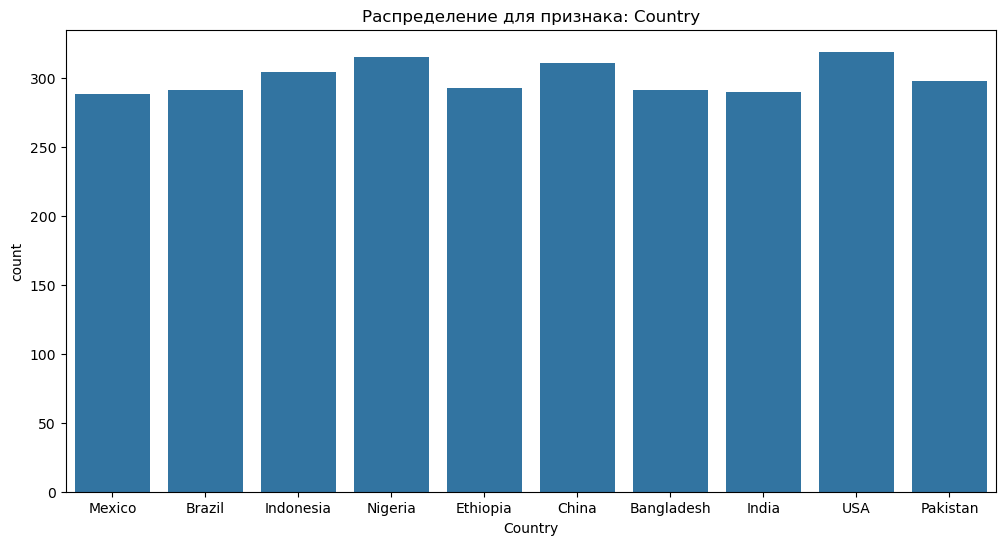

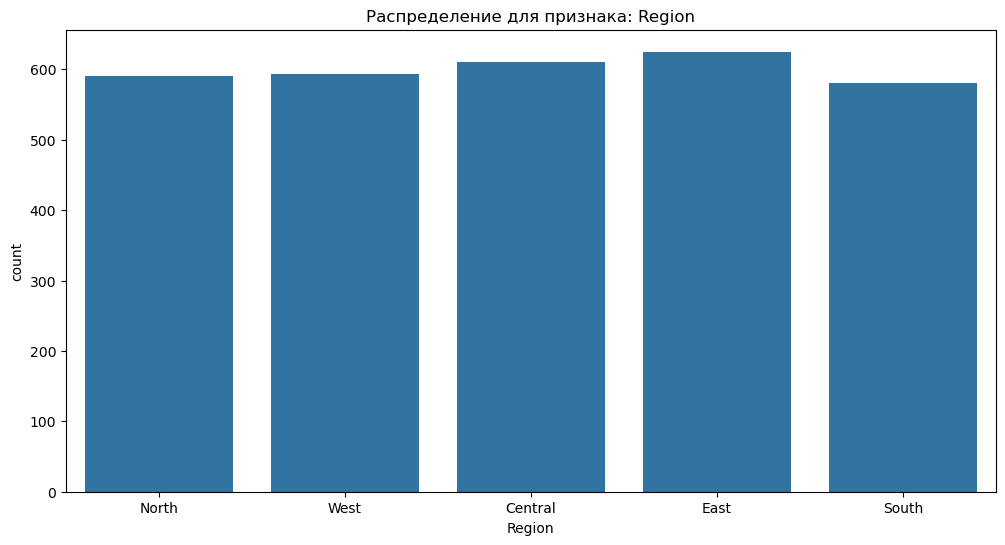

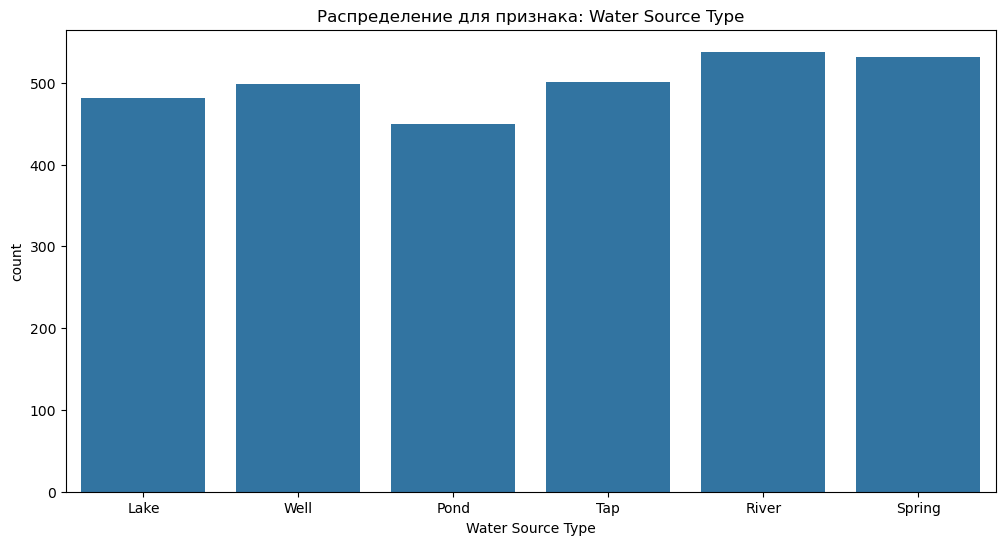

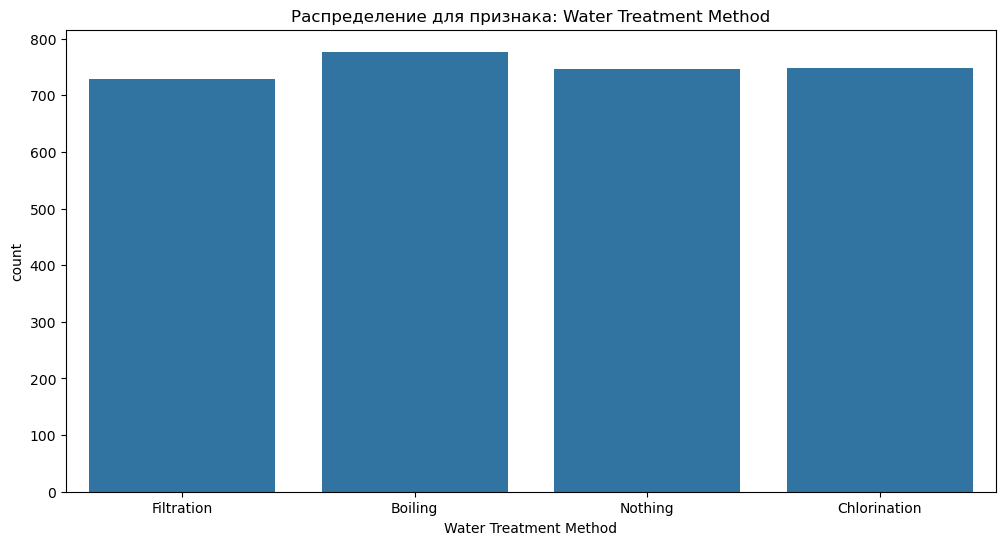

In [24]:
for col in cat_data.columns:
    plt.figure(figsize=(12, 6))
    sns.countplot(cat_data, x=col)
    plt.title(f"Распределение для признака: {col}")
    plt.show()

Все категориальные признаки так же распределены равномерно.

## Корреляционный анализ

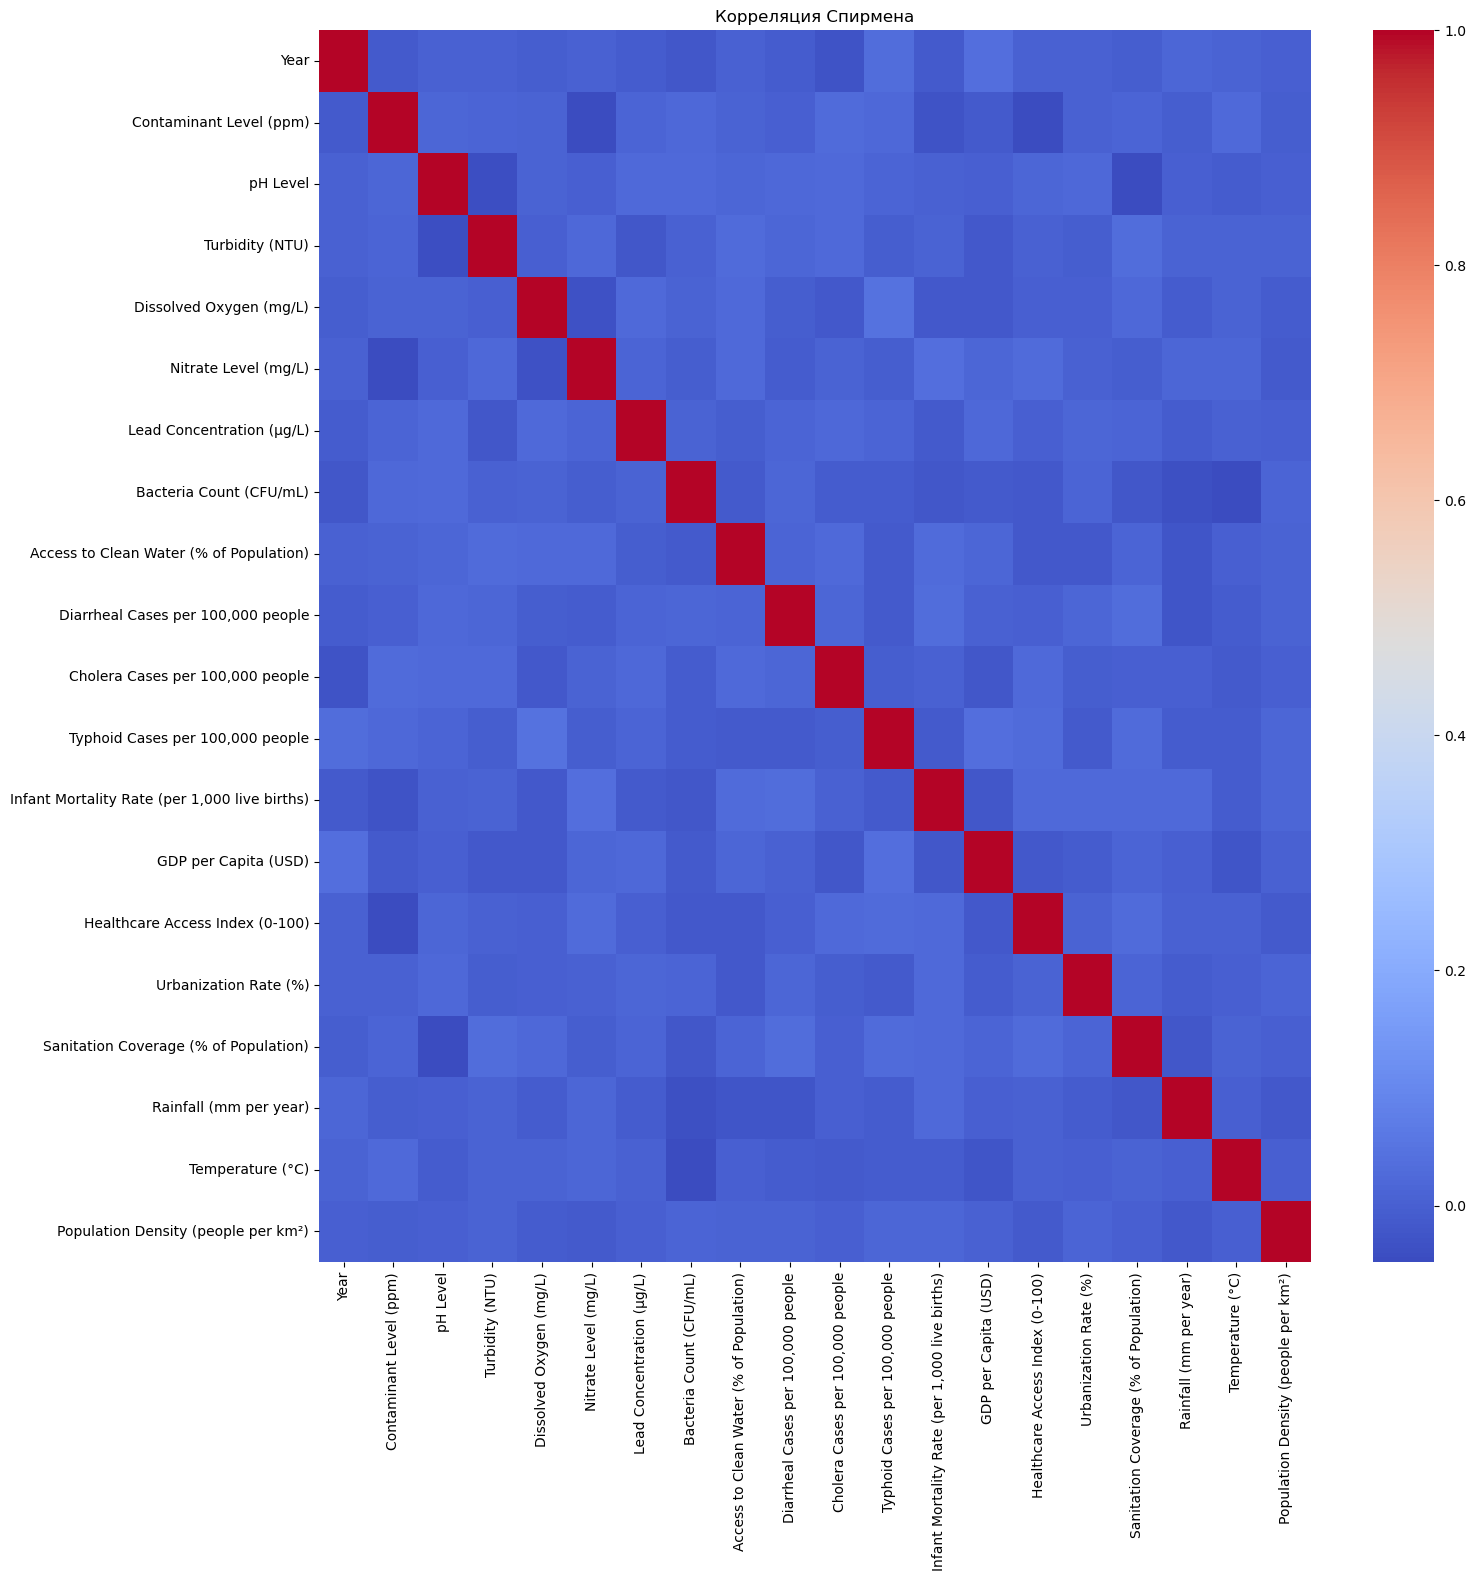

In [19]:
corr_type = "spearman" # Тип корреляции

plt.figure(figsize=(16, 16))
sns.heatmap(numeric_data.corr(corr_type), cmap="coolwarm")
plt.title("Корреляция Спирмена")
plt.show()

<b>Вывод</b>: Числовые признаки между собой не коррелюруют.

Поскольку данные не соответствуют предположению о нормальности распределения (p-value < 0.05), для анализа зависимости был применён коэффициент корреляции Спирмена. Этот метод оценивает монотонную связь, что позволяет выявить нелинейные, но устойчивые зависимости (например, экспоненциальные или логарифмические). График рассеяния подтвердил отсутствие линейности, но показал наличие монотонного роста/убывания значений.

Область применения:

Данные не нормальны (например, имеют скошенность или выбросы).

Связь монотонная (возрастающая или убывающая, но не обязательно линейная).

Наличие ранговых данных или порядковых шкал.


## Корреляция между категориальным признаком и целевой переменной

In [25]:
# Тест Краскела-Уоллиса (категориальный -> непрерывный)
def kruskal_wallis_test(cat_feature, cont_feature):
    groups = []
    for cat in data[cat_feature].unique():
        groups.append(data[data[cat_feature] == cat][cont_feature])
    
    stat, p_value = kruskal(*groups)
    
    if p_value < 0.05:
        return f"p-value = {p_value:.4f}. Есть статистически значимые различия между группами."
    else:
        return f"p-value = {p_value:.4f}. Нет значимых различий между группами."

In [33]:
def get_cat_cont_plots(cat_feature, cont_feature):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    sns.barplot(data=data, x=cat_feature, y=cont_feature, estimator=np.mean, ax=axes[0])
    sns.boxplot(data=data, x=cat_feature, y=cont_feature, ax=axes[1])
    fig.suptitle(f"Распределение для признака: {cat_feature}")
    plt.show()

    print("По тесту Краскела-Уоллиса:", kruskal_wallis_test(cat_feature, cont_feature))

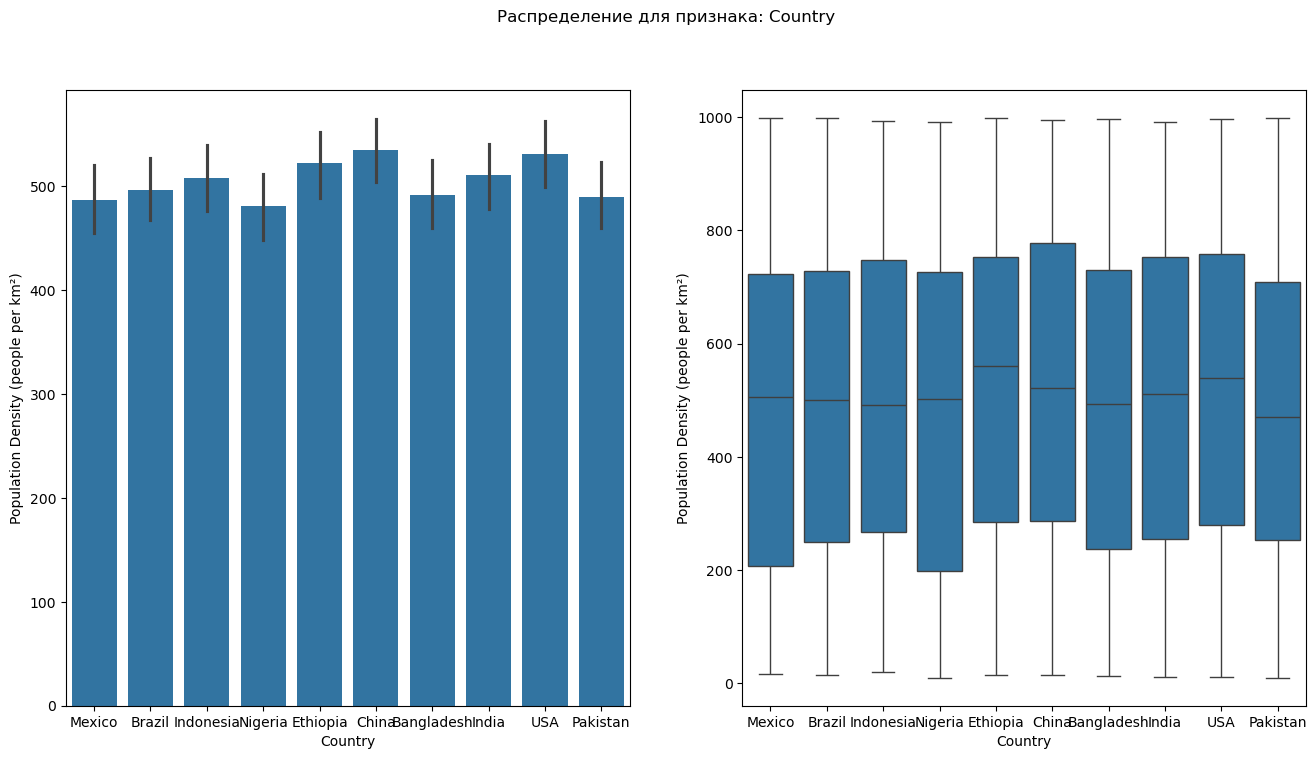

По тесту Краскела-Уоллиса: p-value = 0.1834. Нет значимых различий между группами.


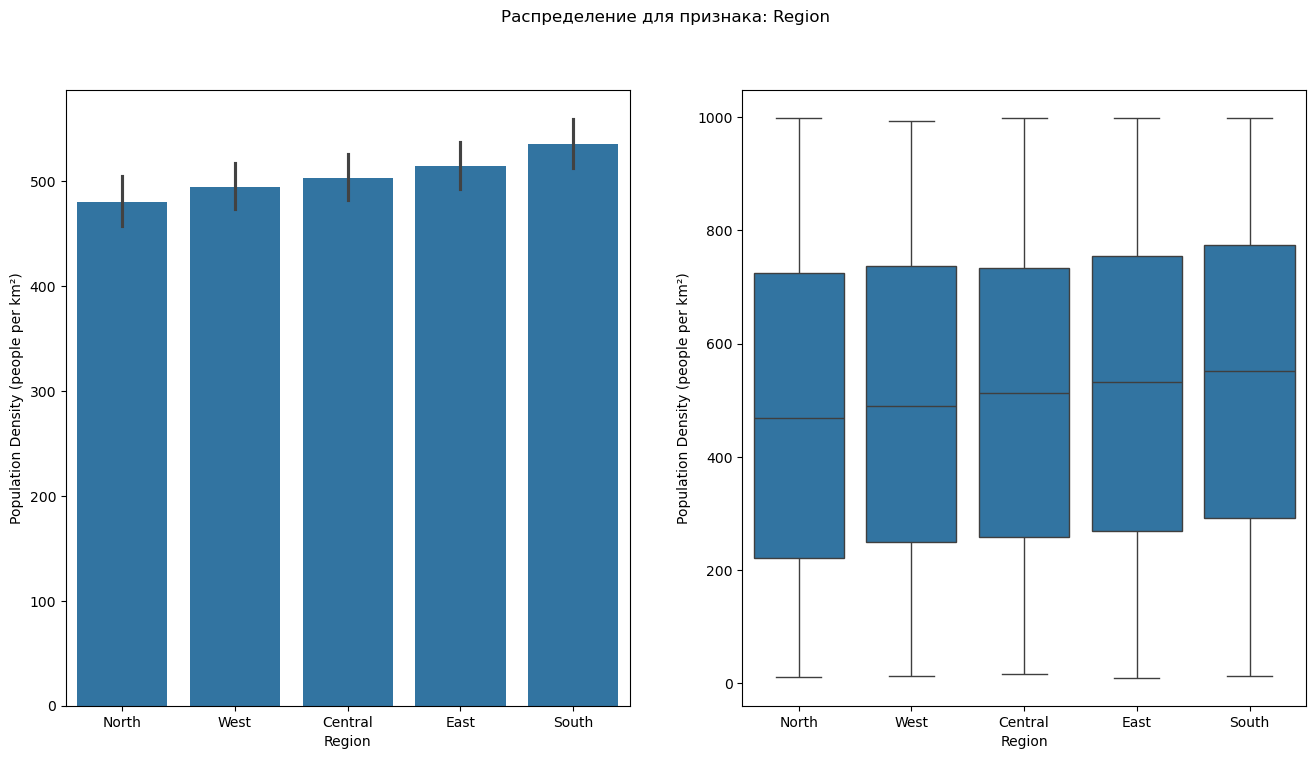

По тесту Краскела-Уоллиса: p-value = 0.0126. Есть статистически значимые различия между группами.


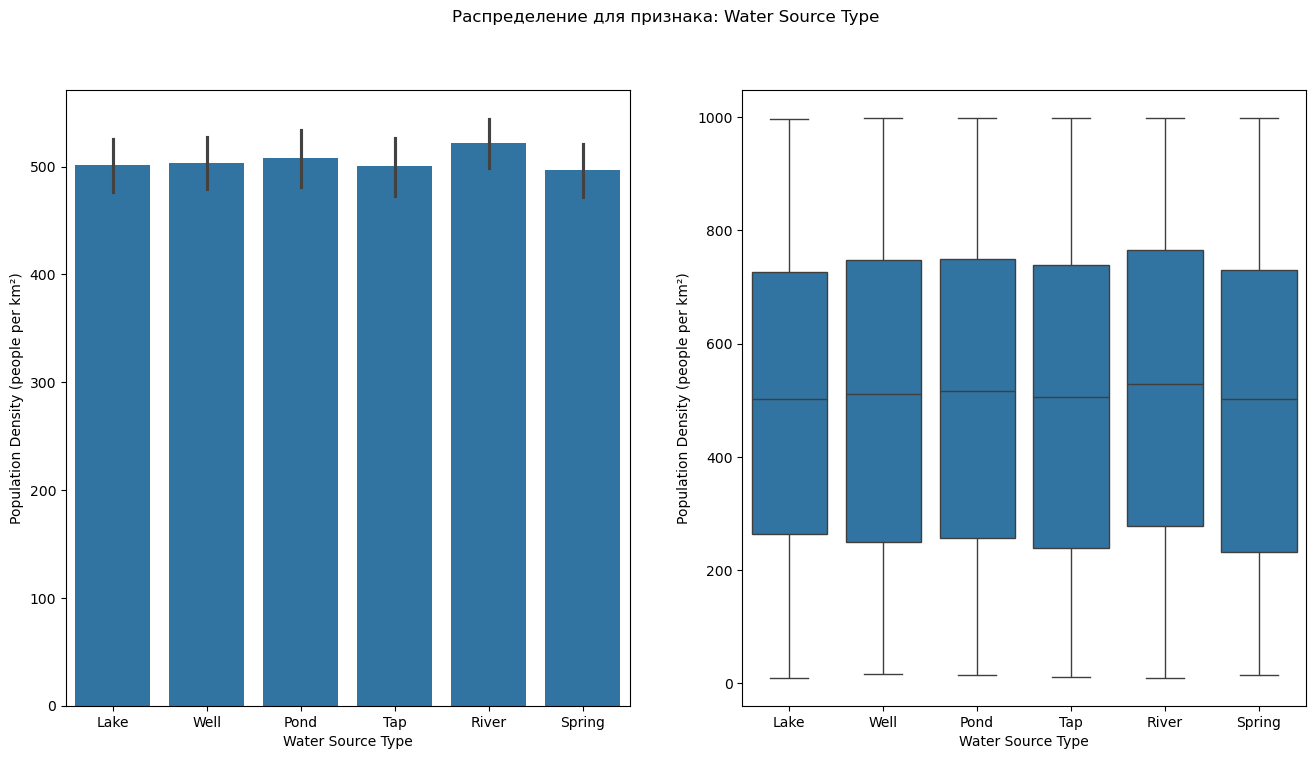

По тесту Краскела-Уоллиса: p-value = 0.7616. Нет значимых различий между группами.


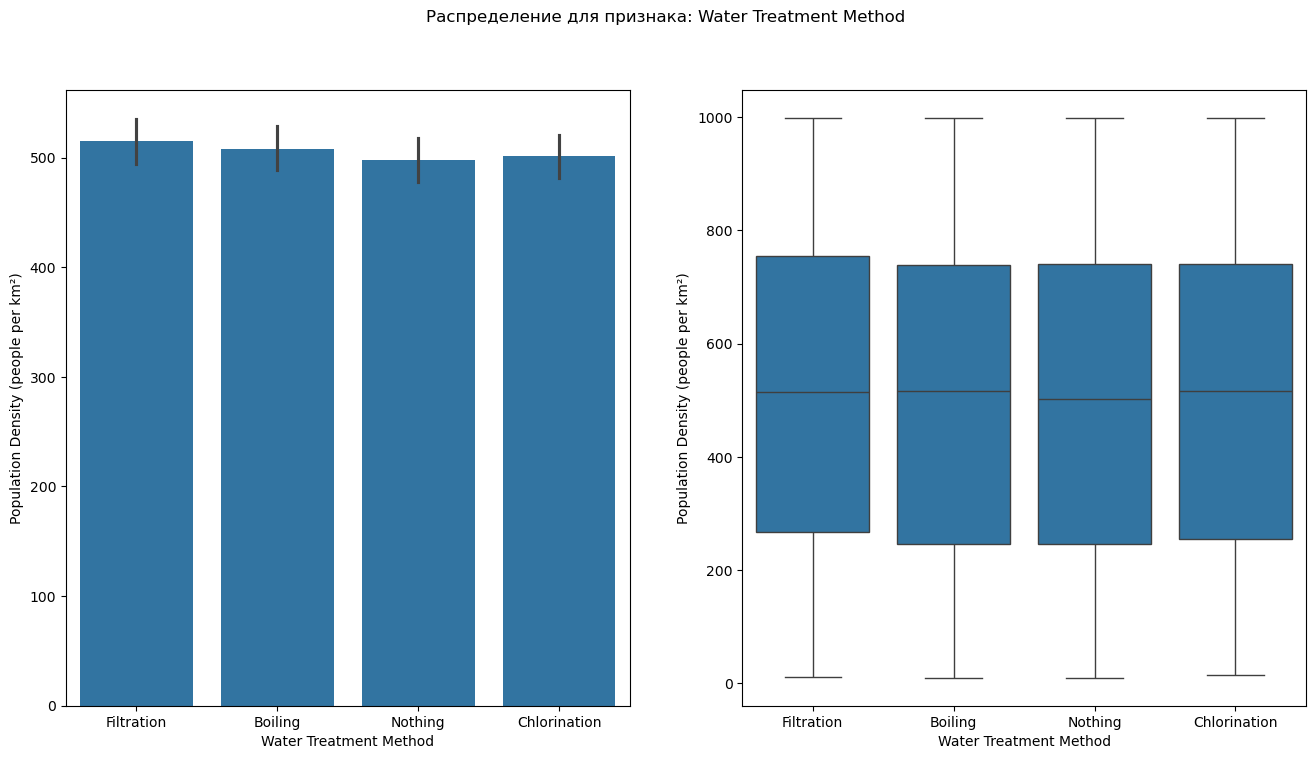

По тесту Краскела-Уоллиса: p-value = 0.6426. Нет значимых различий между группами.


In [34]:
for col in cat_data.columns:
    get_cat_cont_plots(col, "Population Density (people per km²)")

Статистически значимые различия между группами (если отталкиваться от стат теста Краскела-Уоллиса) присутствуют у признака Region.

Тест Краскела-Уоллиса как ядро анализа Этот непараметрический тест является идеальным выбором для сравнения непрерывного признака между несколькими категориальными группами по трём ключевым причинам. Во-первых, он не требует нормального распределения данных внутри групп, что критически важно при работе с реальными данными, которые часто имеют выбросы или асимметрию. Во-вторых, тест устойчив к неравным дисперсиям между группами (гетероскедастичности), что часто встречается на практике. В-третьих, он позволяет сравнивать более двух групп одновременно, в отличие от парных тестов, экономя наши вычислительные ресурсы и избегая проблемы множественных сравнений.

Визуализация через barplot и boxplot Двойная визуализация выполняет две взаимодополняющие функции. Barplot с средними значениями даёт мгновенное понимание центральных тенденций в группах, что особенно полезно для презентации результатов нестатистической аудитории. Boxplot же раскрывает детали распределения - медиану, квартили, выбросы и разброс значений, позволяя оценить гомогенность групп и обнаружить потенциальные аномалии. Такое сочетание графиков обеспечивает полную картину данных.

# Обучение модели

## Подготовка данных для моделей

In [39]:
# Преобразование категориальных признаков в One-Hot Encoded

cat_cols = cat_data.columns # Категориальные признаки

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop="first")

# Применяем к категориальным колонкам
encoded_data = encoder.fit_transform(data[cat_cols])

# Получаем имена новых колонок
feature_names = encoder.get_feature_names_out(cat_cols)

# Создаем DataFrame с закодированными данными
data_encoded = pd.DataFrame(encoded_data, columns=feature_names)

# Объединяем с числовыми колонками
data = pd.concat([data.drop(cat_cols, axis=1), data_encoded], axis=1)

In [45]:
pickle.dump(encoder, open("models/Encoder.sav", 'wb'))

In [41]:
# Разделение на X и Y
X = data.drop("Population Density (people per km²)", axis=1)
y = data["Population Density (people per km²)"]

In [42]:
# Стандартизация признаков (некоторые модели зависимы от масштаба данных)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Year,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),Bacteria Count (CFU/mL),Access to Clean Water (% of Population),"Diarrheal Cases per 100,000 people",...,Region_South,Region_West,Water Source Type_Pond,Water Source Type_River,Water Source Type_Spring,Water Source Type_Tap,Water Source Type_Well,Water Treatment Method_Chlorination,Water Treatment Method_Filtration,Water Treatment Method_Nothing
0,0.413295,0.386632,-0.188586,1.021292,-1.091349,-1.158418,-0.372229,0.597773,-1.527319,1.542280,...,-0.489560,-0.496873,-0.420084,-0.467463,-0.464283,-0.44775,-0.44614,-0.576324,1.766601,-0.575811
1,0.689994,0.099878,0.810937,1.627034,-1.298488,-0.644033,0.799011,-0.256066,1.227657,-0.886799,...,-0.489560,2.012587,-0.420084,-0.467463,-0.464283,-0.44775,2.24145,-0.576324,-0.566059,-0.575811
2,1.381740,-1.648621,-1.146462,-1.190369,-1.515490,0.799141,-0.015165,-0.110732,-1.444089,0.168115,...,-0.489560,-0.496873,2.380476,-0.467463,-0.464283,-0.44775,-0.44614,-0.576324,-0.566059,1.736682
3,0.551645,1.033576,-0.757759,-0.366279,-1.663446,0.816380,-0.565423,0.901717,-0.348796,-1.712686,...,-0.489560,-0.496873,-0.420084,-0.467463,-0.464283,-0.44775,2.24145,-0.576324,-0.566059,-0.575811
4,-0.970197,-1.690585,1.255170,1.225554,1.310472,1.673458,0.424697,1.183303,-1.379573,1.500639,...,2.042649,-0.496873,-0.420084,-0.467463,-0.464283,-0.44775,2.24145,-0.576324,1.766601,-0.575811


In [46]:
pickle.dump(scaler, open("models/Scaler.sav", 'wb'))

In [47]:
# Разделение на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

## Линейная регрессия

In [48]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [49]:
print("Коэффициенты линейной регрессии:")

for feature, coef in zip(X.columns, lr.coef_):
    print(f"{feature}: {coef:.4f}")
    
print(f"\nСвободный член (intercept): {lr.intercept_:.4f}")

Коэффициенты линейной регрессии:
Year: -3.5909
Contaminant Level (ppm): -0.2480
pH Level: -1.2831
Turbidity (NTU): 2.4323
Dissolved Oxygen (mg/L): -8.6304
Nitrate Level (mg/L): -5.4530
Lead Concentration (µg/L): 3.2813
Bacteria Count (CFU/mL): 6.1319
Access to Clean Water (% of Population): 7.1301
Diarrheal Cases per 100,000 people: 4.9906
Cholera Cases per 100,000 people: 0.2657
Typhoid Cases per 100,000 people: 7.9821
Infant Mortality Rate (per 1,000 live births): 6.4063
GDP per Capita (USD): 2.2096
Healthcare Access Index (0-100): -0.9333
Urbanization Rate (%): 3.5840
Sanitation Coverage (% of Population): 0.8198
Rainfall (mm per year): -4.0043
Temperature (°C): -2.3907
Country_Brazil: -1.0262
Country_China: 10.5939
Country_Ethiopia: 11.1943
Country_India: 6.3894
Country_Indonesia: -1.3894
Country_Mexico: -3.0817
Country_Nigeria: -1.3486
Country_Pakistan: -0.6718
Country_USA: 13.8589
Region_East: 6.1910
Region_North: -5.7375
Region_South: 7.3704
Region_West: 4.0018
Water Source Type

## Дерево решений

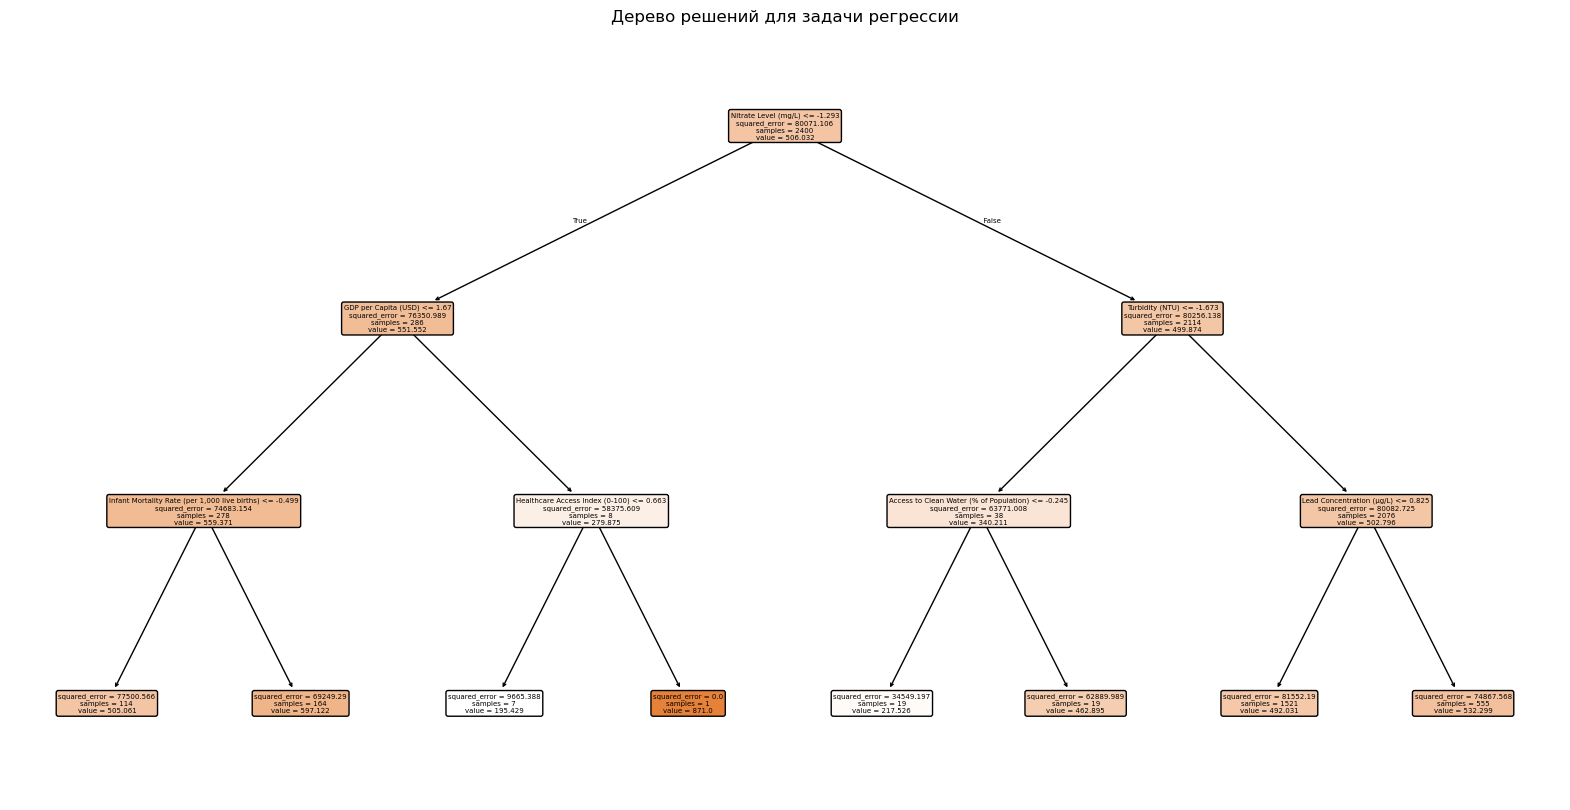

In [ ]:
dtr = DecisionTreeRegressor(max_depth=3, random_state=42)
dtr.fit(X_train, y_train)


y_pred_dtr = dtr.predict(X_test)

#дерево решений
plt.figure(figsize=(20, 10))
plot_tree(dtr, filled=True, feature_names=X.columns, rounded=True)
plt.title("Дерево решений для задачи регрессии")
plt.show()

## Случайный лес

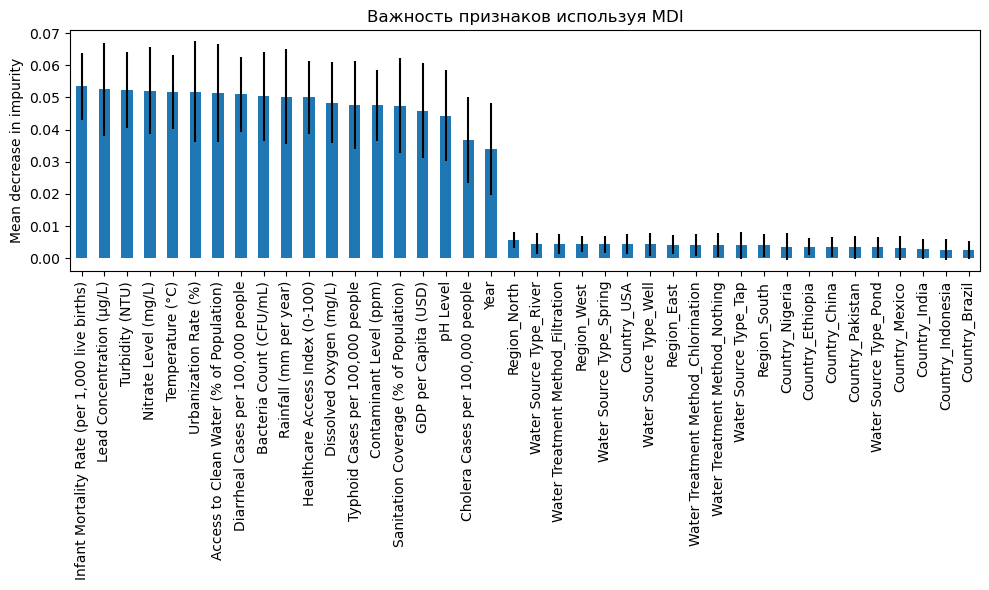

In [56]:
rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train, y_train)

y_pred_rfr = rfr.predict(X_test)



importances = rfr.feature_importances_

std = np.std([tree.feature_importances_ for tree in rfr.estimators_], axis=0)

forest_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)


fig, ax = plt.subplots(figsize=(10, 6))
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Важность признаков используя MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()



## Градиентный бустинг

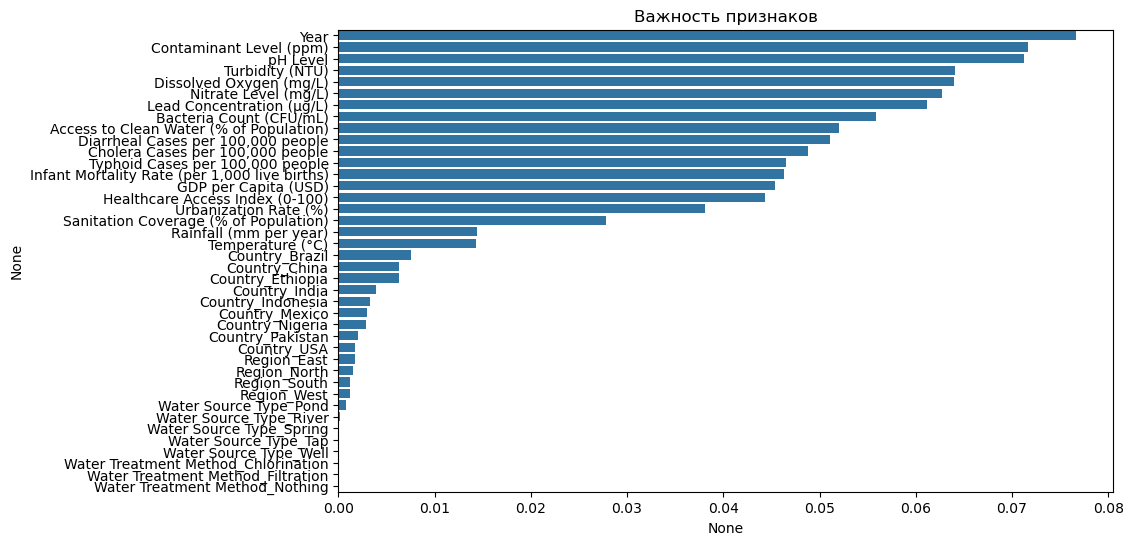

In [57]:
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

# важность признаков
feature_importance = gb.feature_importances_

gb_importance = pd.Series(feature_importance, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=gb_importance, y=X.columns)
plt.title("Важность признаков")
plt.show()



## Сравнение моделей

In [58]:
#функция для оценки модели
def evaluate_model(y_true, y_pred_list, model_list):
    df_result = pd.DataFrame(columns= ['model','mae','rmse','r2'])
    for i,k in zip(y_pred_list, model_list):
        mae = mean_absolute_error(y_true, i)
        mse = mean_squared_error(y_true, i)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true, i)
        df_result.loc[len(df_result)]=[k,mae,rmse,r2]
    return df_result

In [61]:
df_result = evaluate_model(y_test,[y_pred_lr,y_pred_dtr,y_pred_rfr,y_pred_gb],['Линейная регрессия','Дерево решений','Случайный лес','Градиентный бустинг'])
df_result

,model,mae,rmse,r2
0,Линейная регрессия,246.647032,286.343760,-0.014789
1,Дерево решений,246.870203,288.454415,-0.029804
2,Случайный лес,247.188933,288.913956,-0.033088
3,Градиентный бустинг,245.887856,287.333164,-0.021814


Лучший результат показала модель GradientBoostingRegressor

## Оптимизация параметров модели

In [66]:
gb = GradientBoostingRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5]
}

In [64]:
scoring = {
    'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
    'MSE': make_scorer(mean_squared_error, greater_is_better=False),
    'R2': make_scorer(r2_score)
}

In [67]:
grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    scoring=scoring,
    refit='R2',
    cv=3, 
    n_jobs=-1,  
    verbose=2  
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 54 candidates, totalling 162 fits
[CV] END learning_rate=0.01, max_depth=3, min_samples_split=2, n_estimators=100; total time=   1.2s
[CV] END learning_rate=0.01, max_depth=3, min_samples_split=2, n_estimators=100; total time=   1.7s
[CV] END learning_rate=0.01, max_depth=3, min_samples_split=2, n_estimators=100; total time=   1.0s
[CV] END learning_rate=0.01, max_depth=3, min_samples_split=2, n_estimators=200; total time=   2.4s
[CV] END learning_rate=0.01, max_depth=3, min_samples_split=2, n_estimators=200; total time=   2.4s
[CV] END learning_rate=0.01, max_depth=3, min_samples_split=2, n_estimators=200; total time=   2.2s
[CV] END learning_rate=0.01, max_depth=3, min_samples_split=2, n_estimators=300; total time=   3.9s
[CV] END learning_rate=0.01, max_depth=3, min_samples_split=2, n_estimators=300; total time=   3.3s
[CV] END learning_rate=0.01, max_depth=3, min_samples_split=2, n_estimators=300; total time=   3.2s
[CV] END learning_rate=0.01, max_depth

GridSearchCV(cv=3, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5], 'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             refit='R2',
             scoring={'MAE': make_scorer(mean_absolute_error, greater_is_better=False, response_method='predict'),
                      'MSE': make_scorer(mean_squared_error, greater_is_better=False, response_method='predict'),
                      'R2': make_scorer(r2_score, response_method='predict')},
             verbose=2)

In [68]:
print("Лучшие параметры:", grid_search.best_params_)
print("Лучший R2-score:", grid_search.best_score_)

Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
Лучший R2-score: -0.016006390518430818


In [70]:
pickle.dump(grid_search, open("models/GradientBoostingRegressor.sav", 'wb'))